# S&P 500 Equity+Options: Strategy Assessment

This notebook closes the corrected v3.1 validation pipeline without reopening
the 2021 holdout. It traces one primary-label carrier from the equal-weight
baseline through allocation, costs, and fixed risk controls, then reads the
sealed holdout the research lock already records and reports exactly how the
fit it was spent on differs from the one the carrier publishes.

**Learning objectives**

1. Reconstruct the current carrier from configured, full-coverage registry
   rows rather than from the global maximum Sharpe.
2. Read stage progression, cost survival, paired risk uncertainty, and
   selection adjustment as distinct diagnostics.
3. Enforce one holdout use when methodology repairs change the validation
   carrier after the holdout has already been observed.
4. Produce a publication assessment that distinguishes validation evidence
   from unresolved out-of-sample efficacy.

**Book reference:** Chapter 20, Sections 20.1, 20.6, and 20.7.

**Prerequisites:** notebooks `14_backtest` through `17_risk_management` and
their corrected v3.1 registry rows. This notebook is read-only: it trains no
model, runs no backtest, and writes no registry result.

**Population scope:** The case study uses a current-constituent roster rather
than point-in-time S&P 500 membership. Historical results describe this
retrospective roster and do not establish performance for the index's
membership process or a prospective S&P 500 population.

In [1]:
"""S&P 500 Equity+Options: corrected strategy assessment."""

import json
import sqlite3
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

Shared helpers reconstruct the configured funnel and its uncertainty from
registry artifacts without launching another training or evaluation run.

In [2]:
from case_studies.research import Study
from case_studies.utils.backtest_loaders import get_backtest_config
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    set_backtest_costs_bps,
    set_backtest_costs_per_share,
    strategy_view,
)
from case_studies.utils.cv_window import canonical_window
from case_studies.utils.notebook_contracts import prediction_members_in_force
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_backtest_fold_metrics,
    read_predictions,
    resolve_best_backtest_runs,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_cost_grid_bps,
    get_cost_grid_half_spread_usd,
    get_per_share_commission,
    get_position_risk_controls,
    get_top_n_predictions,
)
from case_studies.utils.uncertainty import (
    compute_cohort_metrics,
    compute_paired_uncertainty,
    load_daily_returns_with_timestamp,
    periods_per_year_from_setup,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title

In [3]:
CASE_STUDY = "sp500_equity_option_analytics"
SEED = 42

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY)
REGISTRY_DB = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY)
LABEL = bt_config.primary_label
PERIODS_PER_YEAR = periods_per_year_from_setup(CASE_STUDY)
CONFIGURED_COST_BPS = bt_config.commission_bps + bt_config.slippage_bps
set_global_seeds(SEED)

print(f"Case study: {CASE_STUDY}; corrected label: {LABEL}; mode: registry read-only")

Case study: sp500_equity_option_analytics; corrected label: fwd_ret_5d; mode: registry read-only


## 1. Reconstruct the corrected carrier

The funnel advances the full-coverage baseline configurations `setup.yaml`
declares for the allocation stage on the primary label, filters allocation rows
to the allocators it declares, and filters risk rows to the predeclared
controls. Historical conformal rows, alternate labels, and full-validation
MAE-calibrated rules cannot enter.

Coverage is measured against the canonical validation window
(``coverage_window="canonical"``), not the raw stored day count: this
registry's sweep predates the outcome-horizon boundary, and some checkpoints
carry a few decision dates from before it that inflate their raw count without
covering any more of the modeling window.

**The advancing configurations are drawn from the populations in force, not from every generation
the registry holds.** A population is immutable and refitting one publishes a snapshot that
supersedes the old, with both left readable; nothing in the read path filters on that
(`case_studies/utils/registry/queries.py` contains no occurrence of `supersed`). Unfiltered, a
retired generation competes for a slot against its own replacement, and the funnel below reports
fewer distinct strategies than it appears to. The set is passed into the query rather than
applied to its output because it also scopes the full-coverage bar the ranking is measured
against.

In [5]:
# `Study.at` is the read-only form: one root, no activation. These notebooks only read the
# populations - their backtests reach the registry by their own paths - and every other way in
# ends in `activate()`, which rewrites `ML4T_OUTPUT_DIR` process-wide. `open_study` with the
# canonical tier routes to `Study.regenerate`, which refuses unless `features`, `labels` and
# `run_log` are symlinks: true in a maintainer worktree, false in every clean clone and CI run.
# `CASE_DIR` is already the directory this notebook resolved, including under a preview, so
# asking it directly answers for the registry the rest of the notebook reads.
_study = Study.at(CASE_DIR, case_study=CASE_STUDY, entry_point="18_strategy_analysis")
_members, _population_notes = prediction_members_in_force(_study)
for _note in _population_notes:
    print(_note)
CURRENT_MEMBERS = _members
if CURRENT_MEMBERS is not None:
    print(f"{len(CURRENT_MEMBERS):,} prediction sets in the populations in force")

947 prediction sets in the populations in force


In [6]:
top_predictions = resolve_best_predictions(
    CASE_STUDY,
    LABEL,
    split="validation",
    stage="signal",
    top_n=get_top_n_predictions(CASE_STUDY, "allocation"),
    checkpoints_per_config=get_checkpoints_per_config(CASE_STUDY),
    coverage_window="canonical",
    prediction_hashes=CURRENT_MEMBERS,
)
selected_prediction_hashes = top_predictions["prediction_hash"].to_list()
active_allocators = {item["method"] for item in get_allocators(CASE_STUDY)}
baseline_pool = resolve_best_backtest_runs(
    CASE_STUDY,
    LABEL,
    split="validation",
    stage="signal",
    top_n=9999,
    coverage_window="canonical",
    prediction_hashes=CURRENT_MEMBERS,
).filter(pl.col("prediction_hash").is_in(selected_prediction_hashes))
allocation_pool = resolve_best_backtest_runs(
    CASE_STUDY,
    LABEL,
    split="validation",
    stage="allocation",
    top_n=9999,
    coverage_window="canonical",
    prediction_hashes=CURRENT_MEMBERS,
).filter(pl.col("prediction_hash").is_in(selected_prediction_hashes))
candidate_pool = pl.concat([baseline_pool, allocation_pool], how="diagonal_relaxed").unique(
    "backtest_hash"
)

Cost and risk advance the top validation strategy from the union of the
equal-weight baseline and active alternative allocators.

In [7]:
eligible_strategies = []
for row in candidate_pool.iter_rows(named=True):
    strategy = strategy_view(json.loads(row["spec_json"]))
    allocator = strategy.get("allocation", {}).get("method", "equal_weight")
    if allocator == "equal_weight" or allocator in active_allocators:
        eligible_strategies.append(
            {
                **row,
                "allocator": allocator,
                "top_k": strategy.get("signal", {}).get("top_k"),
            }
        )
if not eligible_strategies:
    raise RuntimeError("No eligible corrected baseline or allocation rows found")
strategy_carrier = (
    pl.DataFrame(eligible_strategies).sort("sharpe", descending=True).row(0, named=True)
)

The canonical fold boundary incorporates the five-session outcome horizon: a
decision made on the last validation day has its five-session return observable
before the holdout opens. The registry was swept before that boundary was
adopted, so its last validation fold runs to the holdout start and carries a
horizon's worth of decisions whose outcome is only observable inside the
holdout. The printout below reports how many decisions and return days that
comes to. Everything after it reads the canonical span, which is what keeps the
holdout out of selection.

In [8]:
validation_window = canonical_window(CASE_STUDY, LABEL, split="validation")
if validation_window is None:
    raise RuntimeError(f"No canonical validation window derivable for {LABEL}")


def to_canonical_window(frame: pl.DataFrame | None) -> pl.DataFrame | None:
    """Cut a timestamped artifact to the canonical validation window."""
    if frame is None:
        return None
    return frame.filter(
        pl.col("timestamp").cast(pl.Date).is_between(validation_window[0], validation_window[1])
    )


def canonical_daily_returns(backtest_hash: str) -> pl.DataFrame | None:
    """Registered daily returns for one backtest, cut to the canonical window."""
    return to_canonical_window(load_daily_returns_with_timestamp(CASE_STUDY, backtest_hash))


registered_predictions = read_predictions(CASE_STUDY, strategy_carrier["prediction_hash"])
carrier_predictions = to_canonical_window(registered_predictions)
if carrier_predictions.is_empty():
    raise RuntimeError("The strategy carrier has no decisions in the canonical validation window")
latest_decision = carrier_predictions["timestamp"].max()
latest_decision_date = (
    latest_decision.date() if hasattr(latest_decision, "date") else latest_decision
)
registered_returns = load_daily_returns_with_timestamp(
    CASE_STUDY, strategy_carrier["backtest_hash"]
)
if registered_returns is None:
    raise RuntimeError("The strategy carrier has no registered daily-return artifact")
carrier_returns = to_canonical_window(registered_returns)
# Measured on the UNSEALED frame. Sealing first makes the comparison one-sided: the
# min/max of an already-trimmed frame can only fall short of the window, never past
# it, so a registered artifact that overruns the seal reads as a clean match.
registered_dates = registered_returns["timestamp"].cast(pl.Date)
if registered_dates.is_empty():
    raise RuntimeError("The strategy carrier's registered daily-return artifact is empty")
registered_window = (registered_dates.min(), registered_dates.max())
if registered_window[0] > validation_window[0] or registered_window[1] < validation_window[1]:
    raise RuntimeError(
        "The registered strategy carrier does not cover the canonical validation window: "
        f"registered={registered_window}, canonical={validation_window}"
    )
dropped = len(registered_predictions) - len(carrier_predictions)
dropped_returns = len(registered_returns) - len(carrier_returns)
print(
    f"Canonical validation window: {validation_window[0]} to {validation_window[1]}; "
    f"carrier latest decision: {latest_decision_date}; "
    f"decisions dropped past the window: {dropped}; "
    f"return days dropped past the window: {dropped_returns}"
)

Canonical validation window: 2019-01-07 to 2020-12-23; carrier latest decision: 2020-12-23; decisions dropped past the window: 0; return days dropped past the window: 0


In [9]:
fixed_controls = get_position_risk_controls(CASE_STUDY)
risk_plans = []
base_spec = json.loads(strategy_carrier["spec_json"])
execution = base_spec["backtest_config"]["execution"]
metadata = base_spec["backtest_config"]["metadata"]
stops = base_spec["backtest_config"]["stops"]
if (
    execution["execution_mode"] != "next_bar"
    or execution["execution_price"] != "open"
    or metadata["cadence"] != "weekly_friday_close"
    or metadata["fill_timing"] != "MONDAY_OPEN"
    or stops["trail_stop_timing"] != "lagged"
):
    raise RuntimeError("Carrier execution or stop timing permits same-bar information use")
for control in fixed_controls:
    spec = clone_backtest_spec(base_spec)
    spec["chapter"] = "ch19"
    rule = {"type": control["type"]}
    if control["type"] == "time_exit":
        rule["bars"] = control["bars"]
    else:
        rule["threshold"] = control["threshold"]
    spec["strategy"]["risk"] = {
        "name": control["name"],
        "position_rules": [rule],
    }
    risk_plans.append(
        {
            "risk_name": control["name"],
            "risk_type": control["type"],
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

Exact planned hashes prevent retired or tuned-on-validation rules from
entering the fixed risk-control surface.

In [10]:
risk_hashes = [plan["backtest_hash"] for plan in risk_plans]
with sqlite3.connect(REGISTRY_DB) as db:
    risk_metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.prediction_hash, b.stage,
               bm.sharpe, bm.sharpe_ci95_lo, bm.sharpe_ci95_hi,
               bm.max_drawdown, bm.cagr, bm.total_return
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({",".join("?" for _ in risk_hashes)})
        """,
        connection=db,
        execute_options={"parameters": risk_hashes},
    )
# An empty read comes back with a null-typed join key, which makes the join raise a
# SchemaError before the row-count contract below can report what is actually missing.
risk_metrics = risk_metrics.with_columns(pl.col("backtest_hash").cast(pl.String))
risk_surface = pl.DataFrame(risk_plans).join(risk_metrics, on="backtest_hash", how="inner")
if len(risk_surface) != len(risk_plans):
    raise RuntimeError(
        f"Expected {len(risk_plans)} fixed risk rows for carrier "
        f"{strategy_carrier['prediction_hash']}, found {len(risk_surface)}"
    )
if risk_surface.filter(pl.col("stage") != "risk_overlay").height:
    raise RuntimeError("A corrected risk hash has the wrong registry stage")
no_overlay = {
    "risk_name": "No overlay",
    "risk_type": "none",
    "backtest_hash": strategy_carrier["backtest_hash"],
    "prediction_hash": strategy_carrier["prediction_hash"],
    "sharpe": strategy_carrier["sharpe"],
}
risk_candidates = pl.concat([risk_surface, pl.DataFrame([no_overlay])], how="diagonal_relaxed")
risk_leader = risk_candidates.sort("sharpe", descending=True).row(0, named=True)

The equal-weight starting point comes from the same pool the allocation lineage
was drawn from, so baseline and lineage are judged under one eligibility rule.
Querying it separately would re-apply the raw stored day count and drop this
lineage's prediction, which passes coverage only in the canonical window.

In [11]:
carrier_baselines = baseline_pool.filter(
    pl.col("prediction_hash") == strategy_carrier["prediction_hash"]
)
if carrier_baselines.is_empty():
    raise RuntimeError(
        f"No equal-weight baseline row for carrier prediction {strategy_carrier['prediction_hash']}"
    )
baseline_row = carrier_baselines.sort("sharpe", descending=True).row(0, named=True)

The visible carrier path retains the equal-weight starting point, the
highest-Sharpe pre-risk strategy, and the risk decision only when it improves
validation.

In [12]:
carrier_rows = [
    {
        "stage": "Equal weight",
        "backtest_hash": baseline_row["backtest_hash"],
        "sharpe": baseline_row["sharpe"],
    }
]
if strategy_carrier["backtest_hash"] != baseline_row["backtest_hash"]:
    carrier_rows.append(
        {
            "stage": strategy_carrier["allocator"],
            "backtest_hash": strategy_carrier["backtest_hash"],
            "sharpe": strategy_carrier["sharpe"],
        }
    )
if risk_leader["backtest_hash"] != strategy_carrier["backtest_hash"]:
    carrier_rows.append(
        {
            "stage": risk_leader["risk_name"],
            "backtest_hash": risk_leader["backtest_hash"],
            "sharpe": risk_leader["sharpe"],
        }
    )
carrier = pl.DataFrame(carrier_rows)

In [13]:
with sqlite3.connect(REGISTRY_DB) as db:
    carrier_metrics = pl.read_database(
        f"""
        SELECT backtest_hash, sharpe_ci95_lo, sharpe_ci95_hi, max_drawdown
        FROM backtest_metrics
        WHERE backtest_hash IN ({",".join("?" for _ in carrier["backtest_hash"])})
        """,
        connection=db,
        execute_options={"parameters": carrier["backtest_hash"].to_list()},
    )
carrier = carrier.join(carrier_metrics, on="backtest_hash", how="left")

with sqlite3.connect(REGISTRY_DB) as db:
    carrier_identity = db.execute(
        """
        SELECT t.family, t.config_name
        FROM prediction_sets p
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE p.prediction_hash = ? AND p.split = 'validation'
        """,
        (strategy_carrier["prediction_hash"],),
    ).fetchone()
if carrier_identity is None:
    msg = (
        f"No validation training_runs row for carrier prediction "
        f"{strategy_carrier['prediction_hash']}. The registry is missing the "
        f"training run this prediction was registered under."
    )
    raise RuntimeError(msg)
carrier_family, carrier_config = carrier_identity

print(
    f"Carrier: prediction={strategy_carrier['prediction_hash']}; "
    f"model={carrier_family}/{carrier_config}; "
    f"allocator={strategy_carrier['allocator']}; top_k={strategy_carrier['top_k']}; "
    f"risk={risk_leader['risk_name']}"
)
print(
    "Validation Sharpe by stage: "
    + " -> ".join(
        f"{stage} {sharpe:.3f}"
        for stage, sharpe in zip(
            carrier["stage"].to_list(), carrier["sharpe"].to_list(), strict=True
        )
    )
)
carrier

Carrier: prediction=603be304fcf3; model=latent_factors/sae; allocator=mvo_ledoit_wolf; top_k=5; risk=trailing_5pct
Validation Sharpe by stage: Equal weight 0.939 -> mvo_ledoit_wolf 1.600 -> trailing_5pct 1.966


stage,backtest_hash,sharpe,sharpe_ci95_lo,sharpe_ci95_hi,max_drawdown
str,str,f64,f64,f64,f64
"""Equal weight""","""96fbc955f7c5""",0.939494,-0.265791,2.314801,-0.35346
"""mvo_ledoit_wolf""","""2520f9995f63""",1.599784,0.168643,2.747081,-0.470373
"""trailing_5pct""","""d0b2d2ebbba1""",1.965796,0.856575,2.844317,-0.239555


The printout above names the corrected primary-label carrier and its Sharpe
at each stage of the funnel. Read the model, allocator, and risk rule from
that line rather than from a fixed description here: eligibility is measured
against the canonical window, so what advances is whatever the corrected filter
selects, not a name pinned in prose.

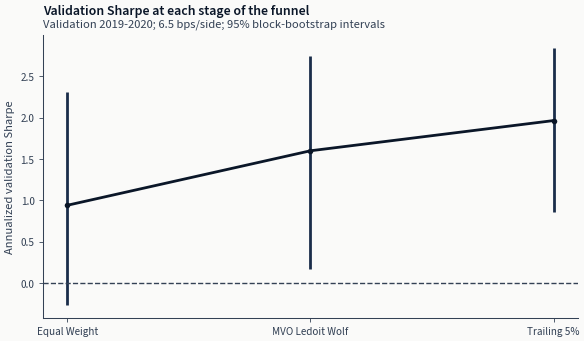

In [14]:
fig_stage, ax_stage = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
x = list(range(len(carrier)))
points = carrier["sharpe"].to_list()
lower = carrier["sharpe_ci95_lo"].to_list()
upper = carrier["sharpe_ci95_hi"].to_list()
ax_stage.errorbar(
    x,
    points,
    yerr=[
        [point - lo for point, lo in zip(points, lower, strict=True)],
        [hi - point for point, hi in zip(points, upper, strict=True)],
    ],
    marker="o",
    color=COLORS["blue"],
    ecolor=COLORS["slate"],
    capsize=4,
    linewidth=2,
)
ax_stage.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)


_ACRONYMS = {"mvo", "hrp", "gbm", "sdf", "sae", "ipca", "lstm"}


def as_label(name: str) -> str:
    """Registry identifier rendered for a chart axis or title."""
    words = []
    for word in name.replace("_", " ").split():
        if word.lower() in _ACRONYMS:
            words.append(word.upper())
        elif word.endswith("pct") and word[:-3].isdigit():
            words.append(f"{word[:-3]}%")
        else:
            words.append(word.capitalize())
    return " ".join(words)


ax_stage.set_xticks(x, [as_label(stage) for stage in carrier["stage"].to_list()])
ax_stage.set_ylabel("Annualized validation Sharpe")
add_message_title(
    ax_stage,
    "Validation Sharpe at each stage of the funnel",
    f"Validation 2019-2020; {CONFIGURED_COST_BPS:.1f} bps/side; 95% block-bootstrap intervals",
)
fig_stage.show()

## 2. Cost survival on the same allocation lineage

The cost diagnostic is measured on the allocation lineage, before the risk rule.
Exact planned hashes keep alternate lineages and removed allocators out of the
curve.

In [15]:
cost_plans = []
for cost_bps in get_cost_grid_bps(CASE_STUDY):
    spec = set_backtest_costs_bps(
        clone_backtest_spec(base_spec),
        commission_bps=cost_bps / 2,
        slippage_bps=cost_bps / 2,
    )
    spec["chapter"] = "ch18"
    cost_plans.append(
        {
            "regime": "bps",
            "cost_value": float(cost_bps),
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

The per-share companion uses the same carrier and changes only the cost
convention.

In [16]:
for half_spread in get_cost_grid_half_spread_usd(CASE_STUDY):
    spec = set_backtest_costs_per_share(
        clone_backtest_spec(base_spec),
        per_share=get_per_share_commission(CASE_STUDY),
        default_half_spread_usd=half_spread,
    )
    spec["chapter"] = "ch18"
    cost_plans.append(
        {
            "regime": "per_share",
            "cost_value": float(half_spread),
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

In [17]:
cost_hashes = [plan["backtest_hash"] for plan in cost_plans]
with sqlite3.connect(REGISTRY_DB) as db:
    cost_metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.stage, bm.sharpe,
               bm.sharpe_ci95_lo, bm.sharpe_ci95_hi
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({",".join("?" for _ in cost_hashes)})
        """,
        connection=db,
        execute_options={"parameters": cost_hashes},
    )
cost_metrics = cost_metrics.with_columns(pl.col("backtest_hash").cast(pl.String))
cost_surface = pl.DataFrame(cost_plans).join(cost_metrics, on="backtest_hash", how="inner")
if len(cost_surface) != len(cost_plans):
    raise RuntimeError(
        f"Expected {len(cost_plans)} cost rows for carrier "
        f"{strategy_carrier['prediction_hash']}, found {len(cost_surface)}"
    )
if cost_surface.filter(pl.col("stage") != "cost_sensitivity").height:
    raise RuntimeError("A corrected cost hash has the wrong registry stage")

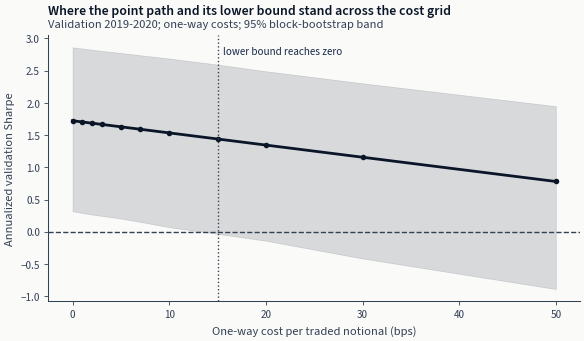

In [18]:
bps = cost_surface.filter(pl.col("regime") == "bps").sort("cost_value")


def first_zero_cost(column: str) -> float | None:
    """Lowest grid cost at which `column` reaches zero, or None if it never does."""
    reached = bps.filter(pl.col(column) <= 0)
    return reached["cost_value"].min() if reached.height else None


first_crossing = first_zero_cost("sharpe_ci95_lo")
point_crossing = first_zero_cost("sharpe")
max_bps = bps["cost_value"].max()

fig_cost, ax_cost = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
ax_cost.plot(
    bps["cost_value"],
    bps["sharpe"],
    marker="o",
    color=COLORS["blue"],
    linewidth=2,
)
ax_cost.fill_between(
    bps["cost_value"],
    bps["sharpe_ci95_lo"],
    bps["sharpe_ci95_hi"],
    color=COLORS["blue"],
    alpha=0.14,
)
ax_cost.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)
ax_cost.set_xlabel("One-way cost per traded notional (bps)")
ax_cost.set_ylabel("Annualized validation Sharpe")
if first_crossing is not None:
    ax_cost.axvline(first_crossing, color=COLORS["neutral"], linestyle=":", linewidth=1)
    ax_cost.annotate(
        "lower bound reaches zero",
        (first_crossing, ax_cost.get_ylim()[1]),
        xytext=(4, -8),
        textcoords="offset points",
        fontsize=8,
        color=COLORS["slate"],
        va="top",
    )
add_message_title(
    ax_cost,
    "Where the point path and its lower bound stand across the cost grid",
    "Validation 2019-2020; one-way costs; 95% block-bootstrap band",
)
fig_cost.show()

In [19]:
def _crossing(cost: float | None) -> str:
    return f"{cost:.0f} bps" if cost is not None else "not within the grid"


print(
    f"Lower bound first reaches zero: {_crossing(first_crossing)}; "
    f"point Sharpe first reaches zero: {_crossing(point_crossing)}; "
    f"grid runs to {max_bps:.0f} bps one-way, where point Sharpe is {bps['sharpe'][-1]:.3f}"
)

Lower bound first reaches zero: 15 bps; point Sharpe first reaches zero: not within the grid; grid runs to 50 bps one-way, where point Sharpe is 0.780


The printout above gives the cost at which each of the two first reaches zero,
or says that it does not inside the grid. The lower bound's crossing, not the
point path's, is what bounds a cost claim: a point Sharpe still above zero with
a band that straddles it is a robustness result, not an estimate of net
performance.

## 3. Paired risk effect and risk-cohort selection adjustment

The leading overlay is compared with its exact allocation baseline on aligned
timestamps. The risk-only cohort then asks how much of that apparent lead
could arise from choosing among the declared controls. It does not erase the earlier
model and allocation search, so it is a lower bound on the total search cost.

In [20]:
baseline_returns = canonical_daily_returns(strategy_carrier["backtest_hash"])
leader_returns = canonical_daily_returns(risk_leader["backtest_hash"])
if baseline_returns is None or leader_returns is None:
    raise RuntimeError("Missing daily returns for the corrected carrier")
aligned = (
    baseline_returns.rename({"ret": "baseline_ret"})
    .join(leader_returns.rename({"ret": "challenger_ret"}), on="timestamp", how="inner")
    .sort("timestamp")
)
if aligned.is_empty():
    raise RuntimeError("The overlay and its baseline are flat across the canonical window")
# `challenger_overlays_baseline` says what a flat session on the challenger means, and here
# the challenger is a risk overlay running on top of this exact carrier. Both are live from
# the carrier's first traded session, so a session the overlay sits out is a position it
# chose to hold and belongs in the comparison - it is the effect being measured. The default
# is for two independent series, where the challenger's leading zeros are a warmup before its
# first signal, and applying it here would delete the overlay's largest effect and pull
# `sharpe_diff` toward zero in the direction the overlay is under test.
paired_risk = compute_paired_uncertainty(
    aligned["challenger_ret"],
    aligned["baseline_ret"],
    periods_per_year=PERIODS_PER_YEAR,
    case_study=CASE_STUDY,
    label=LABEL,
    n_boot=2000,
    seed=SEED,
    challenger_overlays_baseline=True,
)

Selection adjustment uses only the predeclared risk overlays and keeps
the no-overlay carrier as the economic benchmark.

In [21]:
returns_by_hash = {
    backtest_hash: canonical_daily_returns(backtest_hash)
    for backtest_hash in risk_surface["backtest_hash"]
}
fold_returns_by_hash = {
    backtest_hash: load_backtest_fold_metrics(CASE_STUDY, backtest_hash=backtest_hash)[
        "sharpe"
    ].to_numpy()
    for backtest_hash in risk_surface["backtest_hash"]
}
risk_cohort = compute_cohort_metrics(
    returns_by_hash,
    periods_per_year=PERIODS_PER_YEAR,
    baseline_returns=baseline_returns,
    fold_returns_by_hash=fold_returns_by_hash,
    rademacher_n_simulations=2000,
    rademacher_seed=SEED,
)
if (
    risk_leader["risk_type"] != "none"
    and risk_cohort.get("leader_hash") != risk_leader["backtest_hash"]
):
    raise RuntimeError("Risk cohort leader does not match the corrected carrier")

In [22]:
risk_diagnostics = pl.DataFrame(
    [
        {"diagnostic": "Paired Sharpe difference", "value": paired_risk["sharpe_diff"]},
        {"diagnostic": "Paired 95% lower bound", "value": paired_risk["sharpe_diff_ci95_lo"]},
        {"diagnostic": "Paired 95% upper bound", "value": paired_risk["sharpe_diff_ci95_hi"]},
        {"diagnostic": "Bootstrap win probability", "value": paired_risk["prob_challenger_wins"]},
        {"diagnostic": "Risk-cohort DSR ER p-value", "value": risk_cohort["dsr_er_pvalue"]},
        {"diagnostic": "Risk-cohort PBO", "value": risk_cohort["pbo"]},
        {"diagnostic": "Risk-cohort folds", "value": risk_cohort["pbo_n_folds"]},
    ]
)
print(
    f"Paired improvement of {risk_leader['risk_name']} over its allocation baseline: "
    f"{paired_risk['sharpe_diff']:+.3f} "
    f"[{paired_risk['sharpe_diff_ci95_lo']:.3f}, {paired_risk['sharpe_diff_ci95_hi']:.3f}]"
)
risk_diagnostics

Paired improvement of trailing_5pct over its allocation baseline: +0.368 [-0.177, 1.007]


diagnostic,value
str,f64
"""Paired Sharpe difference""",0.367935
"""Paired 95% lower bound""",-0.177344
"""Paired 95% upper bound""",1.007102
"""Bootstrap win probability""",0.8915
"""Risk-cohort DSR ER p-value""",0.004253
"""Risk-cohort PBO""",0.5
"""Risk-cohort folds""",2.0


The paired interval above is the risk rule's own effect, measured against its
exact allocation baseline on aligned timestamps. The selection-adjusted
diagnostics in the same table account for choosing among the fixed
controls, but only two validation folds remain available for temporal
stability analysis, so the cohort statistics rest on a thin sample.

## 4. Holdout status: a sealed evaluation of a superseded fit

The 2021 holdout has been taken once, and the research lock records what it
was spent on. Reading the lock rather than guessing at the lineage is the
point of this section: the holdout is used once, so the only honest question
is what the sealed record already says, not what a second run would say.

The lock names one holdout training run, one holdout prediction set and one
holdout backtest. The comparison below puts that fit beside the carrier
section 1 selected and reports every field of the training identity they
agree on and every field they do not. `sealed_vs_published` is that diff, and
it is what decides whether this is the carrier's holdout or another fit's.

In [23]:
# The obvious check - "does a holdout prediction exist for the carrier's own training hash?" -
# can never answer yes, so it was never a check. The CV geometry is inside the training
# identity and `build_holdout_cv` refuses to derive a holdout CV equal to the validation one,
# so a holdout retrain always earns a training hash distinct from its validation twin. Across
# the nine registries on 2026-08-30, 6,105 prediction sets resolve to exactly one training
# hash carrying two splits, and it is not in this case study. Asking the lock instead is what
# makes the question answerable.
with sqlite3.connect(REGISTRY_DB) as db:
    current_training_hash = db.execute(
        "SELECT training_hash FROM prediction_sets WHERE prediction_hash = ?",
        (strategy_carrier["prediction_hash"],),
    ).fetchone()[0]
    lock_rows = db.execute(
        "SELECT lock_hash, lock_json, state FROM research_locks ORDER BY created_at"
    ).fetchall()
    holdout_rows = db.execute(
        """
        SELECT b.backtest_hash, p.prediction_hash, p.training_hash, t.family, t.label,
               b.spec_json, bm.sharpe, bm.sharpe_ci95_lo,
               bm.sharpe_ci95_hi, bm.max_drawdown
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE p.split = 'holdout'
        ORDER BY bm.sharpe DESC
        """
    ).fetchall()
    published_full_spec = json.loads(
        db.execute(
            "SELECT spec_json FROM training_runs WHERE training_hash = ?",
            (current_training_hash,),
        ).fetchone()[0]
    )

# Whether this registry can answer the question at all, decided before anything is compared.
# Three registries reach this cell and they differ in exactly the way that matters: this case
# study's own holds one lock and one sealed holdout, a reader's clean clone holds neither, and
# the CI fixture holds three holdout backtests and no lock at all while seeding `training_runs`
# with a flat `{family, config_name, label}` spec. Indexing `["computation"]` or `lock_rows[0]`
# unconditionally raised on the last two, which is the failure this whole section exists to
# remove, one level up: an absent measurement reported as something other than an absence.
#
# An unsealed holdout is reported rather than refused. Holdout rows with no lock naming them
# are a real condition - `us_firm_characteristics` is in it, with one holdout prediction and
# no lock - and it means the registry cannot say which selection the window was spent on. But
# a case study in that state still has a terminal notebook to render, and refusing here would
# leave it unable to say so.
if len(lock_rows) > 1:
    raise RuntimeError(f"{len(lock_rows)} research locks; a holdout resolves to exactly one")
HOLDOUT_UNSEALED = bool(holdout_rows) and not lock_rows
if HOLDOUT_UNSEALED:
    print(
        f"{len(holdout_rows)} holdout backtest(s) and no research lock naming them. The "
        "window was spent, and nothing records which selection it was spent on, so no "
        "out-of-sample claim can be attached to the carrier below."
    )

lock = json.loads(lock_rows[0][1]) if lock_rows else {}
LOCK_HASH, LOCK_STATE = (lock_rows[0][0], lock_rows[0][2]) if lock_rows else (None, None)
SEALED_TRAINING_HASH = lock.get("holdout_training_hash")
sealed_spec = (lock.get("holdout_training_spec") or {}).get("computation") or {}
published_spec = published_full_spec.get("computation") or {}
HOLDOUT_ASSESSABLE = bool(lock_rows and sealed_spec and published_spec)
if not HOLDOUT_ASSESSABLE:
    print(
        "Holdout status not assessable from this registry: "
        + (
            "no research lock, and holdout rows that none of them seals"
            if HOLDOUT_UNSEALED
            else "it holds no research lock, so no holdout has been taken here"
            if not lock_rows
            else "the recorded training specifications carry no computation block to compare"
        )
    )

In [24]:
# Every field of the training identity, so agreement and disagreement are both shown rather
# than only the half that supports a conclusion. A bare true/false is not enough here: a
# holdout retrain is *supposed* to differ from its validation twin on the window it fits and
# the rows it predicts, and reporting those beside a genuine divergence would make the two
# look alike. Each disagreement therefore carries why it disagrees, and only
# `SUBSTANTIVE_DIVERGENCE` decides the status below.
_BY_CONSTRUCTION = {
    "cv": "holdout window rather than the validation folds - this is what a holdout is",
    "expected_prediction_keys": "one fold over the holdout rather than two over validation",
}


def _artifact_roles(spec: dict, field: str) -> dict[str, str]:
    entries = spec[field]["files"] if field == "input_data_spec" else spec[field]
    return {entry["role"]: entry["sha256"] for entry in entries}


def _divergence(field: str) -> str:
    """Why this identity field differs, or the empty string when it does not."""
    if published_spec.get(field) == sealed_spec.get(field):
        return ""
    if field in _BY_CONSTRUCTION:
        return _BY_CONSTRUCTION[field]
    if field in {"feature_artifacts", "input_data_spec"}:
        pub, sealed = _artifact_roles(published_spec, field), _artifact_roles(sealed_spec, field)
        moved = sorted(role for role in set(pub) & set(sealed) if pub[role] != sealed[role])
        if moved:
            return f"input artifacts changed: {', '.join(moved)}"
        added = sorted(set(sealed) - set(pub)) or sorted(set(pub) - set(sealed))
        return f"same input digests; only the recorded role set differs ({', '.join(added)})"
    if field == "source_identity":
        return "identity-recording scheme changed; no shared key holds a different value"
    return "differs"


# Empty when the comparison cannot be made, so the frame below is a real answer - nothing to
# compare - rather than a table of fields trivially agreeing because both sides are absent.
_identity_fields = sorted(set(published_spec) | set(sealed_spec)) if HOLDOUT_ASSESSABLE else []
_reasons = {field: _divergence(field) for field in _identity_fields}
sealed_vs_published = pl.DataFrame(
    {
        "identity_field": _identity_fields,
        "agrees": [not _reasons[f] for f in _identity_fields],
        "why_it_differs": [_reasons[f] or "-" for f in _identity_fields],
    },
    schema={"identity_field": pl.String, "agrees": pl.Boolean, "why_it_differs": pl.String},
).sort(["agrees", "identity_field"])

# The fields that differ for a reason other than the holdout window and the recording change.
# Empty means the sealed fit and the published one specify the same computation.
SUBSTANTIVE_DIVERGENCE = sorted(
    field
    for field, why in _reasons.items()
    if why and (why == "differs" or why.startswith("input artifacts changed"))
)
# The selection geometry the lock sealed, against the one the carrier publishes. This is the
# validation CV, not the holdout CV in `sealed_spec`, so it is read from the lock itself.
VALIDATION_CV_MATCHES = HOLDOUT_ASSESSABLE and (
    (lock.get("cv") or {}).get("identity") == (published_spec.get("cv") or {}).get("identity")
)

In [25]:
_sealed = [row for row in holdout_rows if row[2] == SEALED_TRAINING_HASH]
if HOLDOUT_ASSESSABLE and not _sealed:
    raise RuntimeError(
        f"the research lock names holdout training {SEALED_TRAINING_HASH}, and no holdout "
        "backtest in the registry runs on it: the sealed evaluation cannot be read back"
    )
if len(_sealed) > 1:
    raise RuntimeError(f"{len(_sealed)} holdout backtests run on the sealed fit; expected one")

_carrier_strategy = {
    "allocator": strategy_carrier["allocator"],
    "risk": risk_leader["risk_name"],
    "top_k": strategy_carrier["top_k"],
}
if _sealed:
    _row = _sealed[0]
    _sealed_strategy = strategy_view(json.loads(_row[5]))
    sealed_holdout = {
        "lock_hash": LOCK_HASH,
        "lock_state": LOCK_STATE,
        "backtest_hash": _row[0],
        "prediction_hash": _row[1],
        "training_hash": _row[2],
        "family": _row[3],
        "label": _row[4],
        "allocator": _sealed_strategy.get("allocation", {}).get("method"),
        "top_k": _sealed_strategy.get("allocation", {}).get("top_k"),
        "risk": _sealed_strategy.get("risk", {}).get("name"),
        "sharpe": _row[6],
        "sharpe_ci_lo": _row[7],
        "sharpe_ci_hi": _row[8],
        "max_drawdown": _row[9],
    }
    STRATEGY_MATCHES = (
        sealed_holdout["allocator"] == _carrier_strategy["allocator"]
        and sealed_holdout["risk"] == _carrier_strategy["risk"]
        and sealed_holdout["top_k"] == _carrier_strategy["top_k"]
    )
else:
    sealed_holdout = None
    STRATEGY_MATCHES = False
IDENTITY_MATCHES = HOLDOUT_ASSESSABLE and current_training_hash == SEALED_TRAINING_HASH

print(f"Published carrier training hash: {current_training_hash}")
print(f"Sealed holdout training hash:    {SEALED_TRAINING_HASH or 'none'} (lock {LOCK_HASH})")
print(f"Same training identity: {IDENTITY_MATCHES}")
print(
    "Carrier strategy: "
    f"{_carrier_strategy['allocator']} / top {_carrier_strategy['top_k']} / "
    f"{_carrier_strategy['risk']}"
)
if sealed_holdout is not None:
    print(
        "Sealed strategy:  "
        f"{sealed_holdout['allocator']} / top {sealed_holdout['top_k']} / "
        f"{sealed_holdout['risk']}"
    )
    print(f"Same strategy: {STRATEGY_MATCHES}")
pl.DataFrame([sealed_holdout] if sealed_holdout else [])

Published carrier training hash: a8ef783492eb
Sealed holdout training hash:    ee6eb0a2a595 (lock 96da7bfdd85a)
Same training identity: False
Carrier strategy: mvo_ledoit_wolf / top 5 / trailing_5pct
Sealed strategy:  mvo_ledoit_wolf / top 5 / trailing_5pct
Same strategy: True


lock_hash,lock_state,backtest_hash,prediction_hash,training_hash,family,label,allocator,top_k,risk,sharpe,sharpe_ci_lo,sharpe_ci_hi,max_drawdown
str,str,str,str,str,str,str,str,i64,str,f64,f64,f64,f64
"""96da7bfdd85a""","""LOCKED""","""7dee1768fd9f""","""9cd990d0bd97""","""ee6eb0a2a595""","""latent_factors""","""fwd_ret_5d""","""mvo_ledoit_wolf""",5,"""trailing_5pct""",1.545315,-0.485329,3.682673,-0.114635


In [26]:
# Which identity fields the sealed fit and the published one disagree on. This is the whole
# basis for the status below, so it is printed rather than summarised.
sealed_vs_published

identity_field,agrees,why_it_differs
str,bool,str
"""cv""",false,"""holdout window rather than the…"
"""expected_prediction_keys""",false,"""one fold over the holdout rath…"
"""feature_artifacts""",false,"""same input digests; only the r…"
"""input_data_spec""",false,"""same input digests; only the r…"
"""source_identity""",false,"""identity-recording scheme chan…"
…,…,…
"""numerical_runtime""",true,"""-"""
"""runtime""",true,"""-"""
"""runtime_identity""",true,"""-"""


In [27]:
# The two questions the prose below rests on, answered rather than asserted.
print(f"Validation CV the lock sealed matches the published carrier's: {VALIDATION_CV_MATCHES}")
print(f"Substantive identity divergence: {SUBSTANTIVE_DIVERGENCE or 'none'}")

Validation CV the lock sealed matches the published carrier's: True
Substantive identity divergence: none


The sealed holdout is not a different strategy and not a different model. It runs the same
family, the same label, the same allocation and the same risk rule the carrier publishes.
What it is not is the same *fit*: the two training hashes printed above differ, the sealed
one registered on 2026-08-27 and the published one by `11e_supervised_autoencoder` two days
later.

Five identity fields disagree and the table says why each does. `cv` and
`expected_prediction_keys` differ because a holdout retrain fits a different window and
predicts a different number of rows - that is what makes it a holdout rather than a third
validation fold, and a run where they agreed would be the broken one. `feature_artifacts`
and `input_data_spec` carry identical digests for every role both record; the sealed spec
additionally records `setup`, which moves the container digest without moving an input.
`source_identity` moved from a map of source-file hashes to the `latent_adapter` /
`latent_model` version pair. `SUBSTANTIVE_DIVERGENCE` is what is left once those are
accounted for, and it is empty: the model specification, the label artifact, the feature
names and the validation CV identity the selection was made on are the same.

That is enough to report the number and not enough to claim it. A different training hash
with no supersession row linking it to the published one is, by the registry's own rule, a
generation this case study no longer publishes, and the sealed fit's weights were never
re-derived under the current identity scheme. They cannot be: a holdout is spent once, and
re-taking this one to close the bookkeeping gap would turn the window into another
selection round, which is the one thing it must not become. So the Sharpe above is the
out-of-sample result for a fit that specifies the same computation as the published carrier
and carries a different identity, and it is reported on exactly those terms.

## 5. Publication assessment

The corrected validation record is internally closed: every planned
allocation, cost, and risk hash exists and the selected risk result
reproduces exactly. Closed is not the same as favorable. The gate table below
reports each check on its own terms, and the paired risk interval is the one
to read carefully. The remaining gap is not a computation failure and not a
missing holdout: it is that the holdout was spent on a fit whose training
identity this case study has since replaced.

In [28]:
final_row = carrier.row(len(carrier) - 1, named=True)
stress = bps.sort("cost_value").row(len(bps) - 1, named=True)
assessment = pl.DataFrame(
    [
        {
            "gate": "Corrected validation carrier",
            "status": "PASS",
            "evidence": (
                f"{carrier_family}/{carrier_config} / {strategy_carrier['allocator']} / "
                f"top {strategy_carrier['top_k']} / {risk_leader['risk_name']}"
            ),
        },
        {
            "gate": "Validation Sharpe uncertainty",
            "status": "PASS" if final_row["sharpe_ci95_lo"] > 0 else "INCONCLUSIVE",
            "evidence": (
                f"{final_row['sharpe']:.3f} "
                f"[{final_row['sharpe_ci95_lo']:.3f}, {final_row['sharpe_ci95_hi']:.3f}]"
            ),
        },
        {
            "gate": "Paired risk improvement",
            "status": "PASS" if paired_risk["sharpe_diff_ci95_lo"] > 0 else "INCONCLUSIVE",
            "evidence": (
                f"{paired_risk['sharpe_diff']:+.3f} "
                f"[{paired_risk['sharpe_diff_ci95_lo']:.3f}, "
                f"{paired_risk['sharpe_diff_ci95_hi']:.3f}]"
            ),
        },
        {
            "gate": f"{stress['cost_value']:.0f} bps point stress",
            "status": "PASS" if stress["sharpe"] > 0 else "FAIL",
            "evidence": (
                f"Sharpe {stress['sharpe']:.3f} "
                f"[{stress['sharpe_ci95_lo']:.3f}, {stress['sharpe_ci95_hi']:.3f}]"
            ),
        },
        {
            # Not "did a holdout run" - it did - but whether the fit it ran on is the one
            # published. `STRATEGY_MATCHES` and `IDENTITY_MATCHES` are computed in section 4
            # and carry the two halves of that question.
            "gate": "Holdout on the published fit",
            "status": (
                "UNSEALED"
                if HOLDOUT_UNSEALED
                else "NOT ASSESSED"
                if sealed_holdout is None
                else "PASS"
                if IDENTITY_MATCHES
                else "QUALIFIED"
                if STRATEGY_MATCHES and VALIDATION_CV_MATCHES and not SUBSTANTIVE_DIVERGENCE
                else "INCONCLUSIVE"
            ),
            "evidence": (
                f"{len(holdout_rows)} holdout backtest(s) sealed by no lock"
                if HOLDOUT_UNSEALED
                else "no research lock in this registry; no holdout has been taken"
                if sealed_holdout is None
                else (
                    f"sealed {sealed_holdout['sharpe']:.3f} ["
                    f"{sealed_holdout['sharpe_ci_lo']:.3f}, "
                    f"{sealed_holdout['sharpe_ci_hi']:.3f}]"
                    + (
                        "; same training identity"
                        if IDENTITY_MATCHES
                        else "; same computation, different identity"
                        if STRATEGY_MATCHES and VALIDATION_CV_MATCHES and not SUBSTANTIVE_DIVERGENCE
                        else f"; diverges on {', '.join(SUBSTANTIVE_DIVERGENCE) or 'strategy'}"
                    )
                )
            ),
        },
        {
            "gate": "Deployment claim",
            "status": "FAIL",
            "evidence": "validation-positive is not out-of-sample efficacy",
        },
    ]
)
assessment

gate,status,evidence
str,str,str
"""Corrected validation carrier""","""PASS""","""latent_factors/sae / mvo_ledoi…"
"""Validation Sharpe uncertainty""","""PASS""","""1.966 [0.857, 2.844]"""
"""Paired risk improvement""","""INCONCLUSIVE""","""+0.368 [-0.177, 1.007]"""
"""50 bps point stress""","""PASS""","""Sharpe 0.780 [-0.889, 1.949]"""
"""Holdout on the published fit""","""QUALIFIED""","""sealed 1.545 [-0.485, 3.683]; …"
"""Deployment claim""","""FAIL""","""validation-positive is not out…"


## Key takeaways

1. The corrected v3.1 validation carrier is the model, allocator, top-k, and
   risk rule named in the assessment table above. Eligibility is decided by
   coverage of the canonical validation window, so a checkpoint whose extra
   decision dates fall outside that window earns no advantage.
2. The stage chart shows Sharpe at each stage the funnel actually produced,
   which is between one and three points depending on whether allocation and
   the risk rule each improved on what came before. The interval at every
   stage is wide: the point path moves far more than the uncertainty around it
   narrows.
3. The risk rule's paired improvement is reported with its own interval
   against the exact allocation baseline. Selection adjustment covers the fixed
   controls, but only two validation folds remain for stability analysis.
4. The cost curve is read from its lower bound, not its point path. The cell
   under the cost chart reports where each first reaches zero, and the lower
   bound's crossing is the one a cost claim has to respect.
5. The 2021 holdout was taken, once, and the research lock names what it was
   spent on: the same model, label, allocation and risk rule the carrier
   publishes, fitted two days earlier under the previous identity-recording
   scheme. Section 4 reports that Sharpe with its interval and the exact
   identity fields the sealed fit and the published one disagree on. It is an
   out-of-sample number for a fit the case study no longer publishes, and it
   cannot be closed by a second run without spending the window twice.
6. Publication may present v3.1 as a corrected validation record, but it must
   label out-of-sample efficacy unresolved and make no deployment claim.